In [439]:
from claudette import *
import numpy as np

In [440]:
model = models[3]
model

'claude-opus-4-5'

In [441]:
chat = Chat(model, sp="You are a helpful and concise assistant.")

In [27]:
r = chat("Suggest a concise sklearn-style class that implements Random Fourier Features for approximating the RBF kernel. When fitting, it should take n_components and gamma arguments. Don't use sklearn in your answer.")

In [28]:
r

```python
import numpy as np

class RandomFourierFeatures:
    def __init__(self, n_components=100, gamma=1.0):
        self.n_components = n_components
        self.gamma = gamma
        self.W_ = None
        self.b_ = None
    
    def fit(self, X):
        n_features = X.shape[1]
        # Sample from N(0, 2*gamma) for RBF kernel approximation
        self.W_ = np.random.normal(0, np.sqrt(2 * self.gamma), 
                                    (n_features, self.n_components))
        self.b_ = np.random.uniform(0, 2 * np.pi, self.n_components)
        return self
    
    def transform(self, X):
        projection = X @ self.W_ + self.b_
        return np.sqrt(2 / self.n_components) * np.cos(projection)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)
```

**Usage:**
```python
X = np.random.randn(100, 10)
rff = RandomFourierFeatures(n_components=500, gamma=0.5)
X_transformed = rff.fit_transform(X)

# Verify: transformed dot product ≈ RBF kernel
k_approx = X_transformed @ X_transformed.T
k_true = np.exp(-0.5 * np.sum((X[:, None] - X[None, :]) ** 2, axis=2))
```

The key idea: `cos(w·x + b)` features where `w ~ N(0, 2γ)` and `b ~ U(0, 2π)` approximate the RBF kernel `exp(-γ||x-y||²)` via Bochner's theorem.

<details>

- id: `msg_012h7MneS5Xhrx7W29SrmfnK`
- container: `None`
- content: `[{'citations': None, 'text': "```python\nimport numpy as np\n\nclass RandomFourierFeatures:\n    def __init__(self, n_components=100, gamma=1.0):\n        self.n_components = n_components\n        self.gamma = gamma\n        self.W_ = None\n        self.b_ = None\n    \n    def fit(self, X):\n        n_features = X.shape[1]\n        # Sample from N(0, 2*gamma) for RBF kernel approximation\n        self.W_ = np.random.normal(0, np.sqrt(2 * self.gamma), \n                                    (n_features, self.n_components))\n        self.b_ = np.random.uniform(0, 2 * np.pi, self.n_components)\n        return self\n    \n    def transform(self, X):\n        projection = X @ self.W_ + self.b_\n        return np.sqrt(2 / self.n_components) * np.cos(projection)\n    \n    def fit_transform(self, X):\n        return self.fit(X).transform(X)\n```\n\n**Usage:**\n```python\nX = np.random.randn(100, 10)\nrff = RandomFourierFeatures(n_components=500, gamma=0.5)\nX_transformed = rff.fit_transform(X)\n\n# Verify: transformed dot product ≈ RBF kernel\nk_approx = X_transformed @ X_transformed.T\nk_true = np.exp(-0.5 * np.sum((X[:, None] - X[None, :]) ** 2, axis=2))\n```\n\nThe key idea: `cos(w·x + b)` features where `w ~ N(0, 2γ)` and `b ~ U(0, 2π)` approximate the RBF kernel `exp(-γ||x-y||²)` via Bochner's theorem.", 'type': 'text'}]`
- model: `claude-opus-4-5-20251101`
- role: `assistant`
- stop_reason: `end_turn`
- stop_sequence: `None`
- type: `message`
- usage: `{'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 62, 'output_tokens': 469, 'server_tool_use': None, 'service_tier': 'standard'}`
- stop_details: `None`

</details>

In [460]:
import numpy as np

class RandomFourierFeatures:
    def __init__(self, n_components=100, gamma=1.0):
        self.n_components = n_components
        self.gamma = gamma
        self.W_ = None
        self.b_ = None
    
    def fit(self, X):
        n_features = X.shape[1]
        # Sample from N(0, 2*gamma) for RBF kernel approximation
        self.W_ = np.random.normal(0, np.sqrt(2 * self.gamma), 
                                    (n_features, self.n_components))
        self.b_ = np.random.uniform(0, 2 * np.pi, self.n_components)
        return self
    
    def transform(self, X):
        projection = X @ self.W_ + self.b_
        return np.sqrt(2 / self.n_components) * np.cos(projection)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [442]:
import numpy as np

class RandomFourierFeatures:
    def __init__(self, n_components=100, gamma=1.0):
        # Force n_components to be even for exact splitting
        self.n_components = n_components + (n_components % 2) 
        self.gamma = gamma
        self.W_ = None
    
    def fit(self, X):
        n_features = X.shape[1]
        n_weights = self.n_components // 2
        
        # Sample from N(0, 2*gamma) for RBF kernel approximation
        self.W_ = np.random.normal(0, np.sqrt(2 * self.gamma), 
                                    (n_features, n_weights))
        return self
    
    def transform(self, X):
        projection = X @ self.W_
        
        # Concatenate cos and sin
        Z = np.hstack([np.cos(projection), np.sin(projection)])
        
        # Normalize so the squared norm of every row is EXACTLY 1
        return Z * np.sqrt(1 / (self.n_components // 2))
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [54]:
chat("Did you handle the normalization right? The k_true and k_approx seem to have different magnitudes.")

You're right, there's a mismatch. The issue is in how `gamma` is defined. 

The RBF kernel is `exp(-gamma * ||x-y||²)`, but Bochner's theorem gives us `exp(-||x-y||² / (2σ²))` with `w ~ N(0, 1/σ²)`.

Matching these: `gamma = 1/(2σ²)`, so `σ² = 1/(2*gamma)`, meaning `w ~ N(0, 2*gamma)`.

But your `k_true` uses `exp(-0.5 * ||x-y||²)` which corresponds to `gamma = 0.5`, not `gamma = 0.5` in the sklearn convention.

Here's the corrected version with consistent definitions:

```python
import numpy as np

class RandomFourierFeatures:
    def __init__(self, n_components=100, gamma=1.0):
        self.n_components = n_components
        self.gamma = gamma
        self.W_ = None
        self.b_ = None
    
    def fit(self, X):
        n_features = X.shape[1]
        self.W_ = np.random.normal(0, np.sqrt(2 * self.gamma), 
                                    (n_features, self.n_components))
        self.b_ = np.random.uniform(0, 2 * np.pi, self.n_components)
        return self
    
    def transform(self, X):
        projection = X @ self.W_ + self.b_
        return np.sqrt(2 / self.n_components) * np.cos(projection)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)
```

**Usage with consistent gamma:**
```python
X = np.random.randn(100, 10)
gamma = 0.5

rff = RandomFourierFeatures(n_components=1000, gamma=gamma)
X_transformed = rff.fit_transform(X)

k_approx = X_transformed @ X_transformed.T
k_true = np.exp(-gamma * np.sum((X[:, None] - X[None, :]) ** 2, axis=2))

print(np.abs(k_approx - k_true).mean())  # Should be small
```

The class was correct—the verification code just had the wrong kernel formula. The true RBF kernel should use `exp(-gamma * ||x-y||²)` to match.

<details>

- id: `msg_01KCTNcHirnuYigaAFN4rY71`
- container: `None`
- content: `[{'citations': None, 'text': "You're right, there's a mismatch. The issue is in how `gamma` is defined. \n\nThe RBF kernel is `exp(-gamma * ||x-y||²)`, but Bochner's theorem gives us `exp(-||x-y||² / (2σ²))` with `w ~ N(0, 1/σ²)`.\n\nMatching these: `gamma = 1/(2σ²)`, so `σ² = 1/(2*gamma)`, meaning `w ~ N(0, 2*gamma)`.\n\nBut your `k_true` uses `exp(-0.5 * ||x-y||²)` which corresponds to `gamma = 0.5`, not `gamma = 0.5` in the sklearn convention.\n\nHere's the corrected version with consistent definitions:\n\n```python\nimport numpy as np\n\nclass RandomFourierFeatures:\n    def __init__(self, n_components=100, gamma=1.0):\n        self.n_components = n_components\n        self.gamma = gamma\n        self.W_ = None\n        self.b_ = None\n    \n    def fit(self, X):\n        n_features = X.shape[1]\n        self.W_ = np.random.normal(0, np.sqrt(2 * self.gamma), \n                                    (n_features, self.n_components))\n        self.b_ = np.random.uniform(0, 2 * np.pi, self.n_components)\n        return self\n    \n    def transform(self, X):\n        projection = X @ self.W_ + self.b_\n        return np.sqrt(2 / self.n_components) * np.cos(projection)\n    \n    def fit_transform(self, X):\n        return self.fit(X).transform(X)\n```\n\n**Usage with consistent gamma:**\n```python\nX = np.random.randn(100, 10)\ngamma = 0.5\n\nrff = RandomFourierFeatures(n_components=1000, gamma=gamma)\nX_transformed = rff.fit_transform(X)\n\nk_approx = X_transformed @ X_transformed.T\nk_true = np.exp(-gamma * np.sum((X[:, None] - X[None, :]) ** 2, axis=2))\n\nprint(np.abs(k_approx - k_true).mean())  # Should be small\n```\n\nThe class was correct—the verification code just had the wrong kernel formula. The true RBF kernel should use `exp(-gamma * ||x-y||²)` to match.", 'type': 'text'}]`
- model: `claude-opus-4-5-20251101`
- role: `assistant`
- stop_reason: `end_turn`
- stop_sequence: `None`
- type: `message`
- usage: `{'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 558, 'output_tokens': 623, 'server_tool_use': None, 'service_tier': 'standard'}`
- stop_details: `None`

</details>

In [444]:
X = np.random.randn(1000, 10)
gamma = 1

rff = RandomFourierFeatures(n_components=300, gamma=gamma)
X_transformed = rff.fit_transform(X)

k_approx = X_transformed @ X_transformed.T
k_true = np.exp(-gamma * np.sum((X[:, None] - X[None, :]) ** 2, axis=2))

print(np.abs(k_approx - k_true).mean())  # Should be small

0.04597600126012226


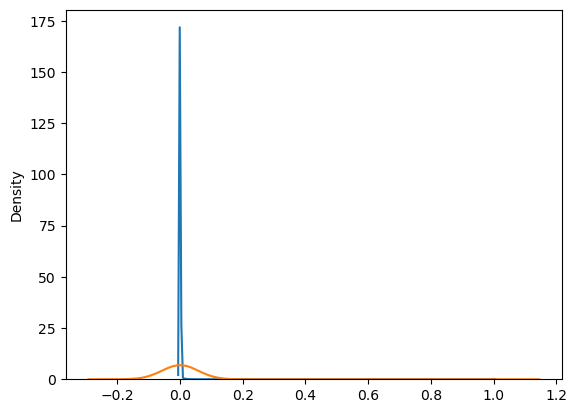

In [445]:
import seaborn as sns

sns.kdeplot(k_true.flatten());
sns.kdeplot(k_approx.flatten());

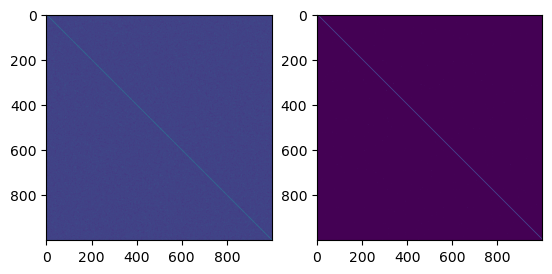

In [446]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2)
ax[0].imshow(k_approx)
ax[1].imshow(k_true)

In [143]:
chat("Suggest a nice sklearn dataset for OOD detection.")

Here are some good sklearn datasets for Out-of-Distribution (OOD) detection:

## 1. **Digits + Letters (Recommended)**

Use digits as in-distribution and letters as OOD:

```python
from sklearn.datasets import load_digits, fetch_openml

# In-distribution: digits 0-9
digits = load_digits()
X_in, y_in = digits.data, digits.target

# OOD: letters from EMNIST or use different dataset
letters = fetch_openml('letter', version=1, as_frame=False)
X_ood = letters.data
```

## 2. **Class Holdout (Simple Approach)**

Hold out some classes as OOD:

```python
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()
X, y = digits.data, digits.target

# In-distribution: digits 0-7
in_mask = y <= 7
X_in, y_in = X[in_mask], y[in_mask]

# OOD: digits 8-9
ood_mask = y > 7
X_ood, y_ood = X[ood_mask], y[ood_mask]
```

## 3. **Covertype Dataset**

Large dataset with natural class imbalance:

```python
from sklearn.datasets import fetch_covtype

covtype = fetch_covtype()
X, y = covtype.data, covtype.target

# Use common classes as in-distribution
in_classes = [1, 2]
ood_classes = [3, 4, 5, 6, 7]

X_in = X[np.isin(y, in_classes)]
X_ood = X[np.isin(y, ood_classes)]
```

## 4. **Wine + Breast Cancer (Cross-domain)**

```python
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler

# In-distribution
wine = load_wine()
X_in = StandardScaler().fit_transform(wine.data)

# OOD (different domain entirely)
cancer = load_breast_cancer()
X_ood = StandardScaler().fit_transform(cancer.data)
```

## **Recommendation**

The **class holdout approach with digits** (#2) is cleanest for OOD detection experiments since:
- Same feature space
- Clear semantic difference
- Easy to visualize and interpret

<details>

- id: `msg_01HMot3GFqH2TNHXRCKCC2BF`
- container: `None`
- content: `[{'citations': None, 'text': "Here are some good sklearn datasets for Out-of-Distribution (OOD) detection:\n\n## 1. **Digits + Letters (Recommended)**\n\nUse digits as in-distribution and letters as OOD:\n\n```python\nfrom sklearn.datasets import load_digits, fetch_openml\n\n# In-distribution: digits 0-9\ndigits = load_digits()\nX_in, y_in = digits.data, digits.target\n\n# OOD: letters from EMNIST or use different dataset\nletters = fetch_openml('letter', version=1, as_frame=False)\nX_ood = letters.data\n```\n\n## 2. **Class Holdout (Simple Approach)**\n\nHold out some classes as OOD:\n\n```python\nfrom sklearn.datasets import load_digits\nimport numpy as np\n\ndigits = load_digits()\nX, y = digits.data, digits.target\n\n# In-distribution: digits 0-7\nin_mask = y <= 7\nX_in, y_in = X[in_mask], y[in_mask]\n\n# OOD: digits 8-9\nood_mask = y > 7\nX_ood, y_ood = X[ood_mask], y[ood_mask]\n```\n\n## 3. **Covertype Dataset**\n\nLarge dataset with natural class imbalance:\n\n```python\nfrom sklearn.datasets import fetch_covtype\n\ncovtype = fetch_covtype()\nX, y = covtype.data, covtype.target\n\n# Use common classes as in-distribution\nin_classes = [1, 2]\nood_classes = [3, 4, 5, 6, 7]\n\nX_in = X[np.isin(y, in_classes)]\nX_ood = X[np.isin(y, ood_classes)]\n```\n\n## 4. **Wine + Breast Cancer (Cross-domain)**\n\n```python\nfrom sklearn.datasets import load_wine, load_breast_cancer\nfrom sklearn.preprocessing import StandardScaler\n\n# In-distribution\nwine = load_wine()\nX_in = StandardScaler().fit_transform(wine.data)\n\n# OOD (different domain entirely)\ncancer = load_breast_cancer()\nX_ood = StandardScaler().fit_transform(cancer.data)\n```\n\n## **Recommendation**\n\nThe **class holdout approach with digits** (#2) is cleanest for OOD detection experiments since:\n- Same feature space\n- Clear semantic difference\n- Easy to visualize and interpret", 'type': 'text'}]`
- model: `claude-opus-4-5-20251101`
- role: `assistant`
- stop_reason: `end_turn`
- stop_sequence: `None`
- type: `message`
- usage: `{'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'inference_geo': 'not_available', 'input_tokens': 681, 'output_tokens': 595, 'server_tool_use': None, 'service_tier': 'standard'}`
- stop_details: `None`

</details>

In [461]:
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split

# In-distribution: digits 0-9
digits = load_digits()
x_tr, x_te, y_tr, y_te = train_test_split(
    digits.data, digits.target, test_size=0.2
)

def mask(y):
    # Outliers are NOT 1, 3, 5, 7
    return ~((y == 1) | (y == 7) | (y == 4))

x_tr = x_tr[~mask(y_tr)] # inliers only
y_true = mask(y_te)

x_tr.shape, x_te.shape, y_true.shape

((437, 64), (360, 64), (360,))

In [462]:
y_true.mean()

np.float64(0.7083333333333334)

In [463]:
from utils.misc import median_heuristic

class RFF_KIC():
    def __init__(self, n_components=100, reg=0):
        self.gamma = median_heuristic(x_tr)
        self.reg = reg
        self.rff = RandomFourierFeatures(n_components=n_components, gamma=self.gamma)

    def fit(self, x_tr):
        z_tr = self.rff.fit_transform(x_tr)
        self.M = z_tr.T @ z_tr / len(z_tr)
        return self

    def score(self, x_te):
        z_te = self.rff.transform(x_te)

        scores = np.diag(z_te @ np.linalg.inv(self.M + self.reg*np.ones(len(self.M))) @ z_te.T)
        return scores

In [464]:
from sklearn.metrics import roc_auc_score

trials = 5
ns = np.arange(1, 1000, step=5)
aurocs = np.zeros((len(ns), trials))
conds = np.zeros((len(ns), trials))
logdets = np.zeros((len(ns), trials))

for n_idx, n in enumerate(ns):
    for i in range(trials):
        rff_kic = RFF_KIC(n_components=n).fit(x_tr)
        scores = rff_kic.score(x_te)
        
        #sns.kdeplot(scores[~y_true], color='green')
        #sns.kdeplot(scores[y_true], color='red')
        
        aurocs[n_idx, i] = roc_auc_score(y_true, scores)
        conds[n_idx, i] = np.linalg.cond(rff_kic.M)
        logdets[n_idx, i] = np.linalg.slogdet(rff_kic.M)[1]

In [474]:
conds = np.log(conds)
conds /= conds.max()

/var/folders/c2/vhmqh4t566q95zcjystvh20c0000gn/T/ipykernel_10174/3832667712.py:1: RuntimeWarning: invalid value encountered in log
  conds = np.log(conds)


In [475]:
logdets[0]

array([-0.19375579,  0.09153276, -0.15830307,  0.43926738,  0.07045478])

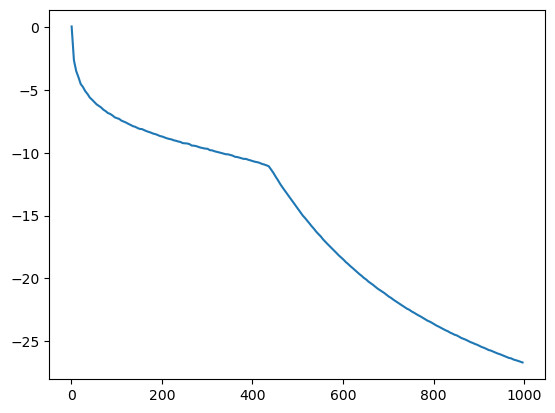

In [476]:
plt.plot(ns, logdets.mean(axis=1) / ns)
#plt.fill_between(ns, logdets.mean(axis=1) - logdets.std(axis=1)/np.sqrt(trials), logdets.mean(axis=1) + logdets.std(axis=1)/np.sqrt(trials), alpha=0.3)

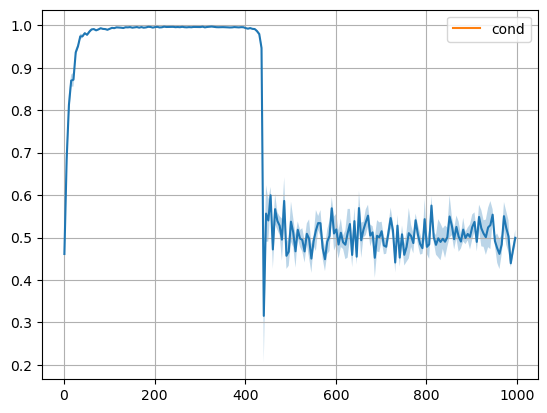

In [477]:
plt.plot(ns, aurocs.mean(axis=1))
plt.fill_between(ns, aurocs.mean(axis=1) - aurocs.std(axis=1)/np.sqrt(trials), aurocs.mean(axis=1) + aurocs.std(axis=1)/np.sqrt(trials), alpha=0.3)

plt.plot(ns, conds.mean(axis=1), label='cond')

plt.grid()
plt.legend()

In [329]:
from algs.kern_cd import *
from algs.kernels.rbf import RBF

k = RBF().fit(x_tr)
p = KernCD(kernel=k, reg=1e-9).fit(x_tr)

0.9951097753553054

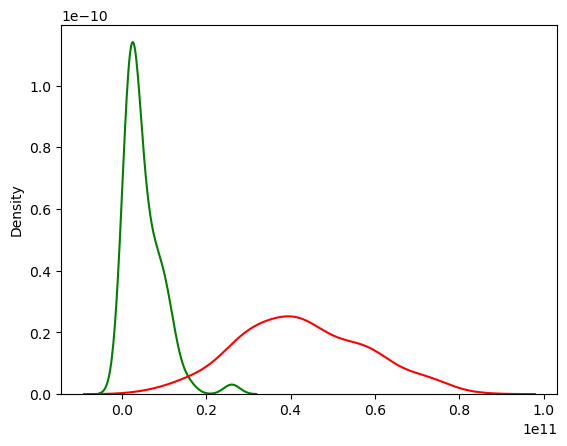

In [330]:
scores2 = p.predict(x_te)

sns.kdeplot(scores2[~y_true], color='green')
sns.kdeplot(scores2[y_true], color='red')

roc_auc_score(y_true, scores2)

In [272]:
np.abs(scores - scores2).mean()

np.float64(32103025271.090385)

## MVTech AD

In [530]:
!pixi add --pypi anomalib

⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4                                                                             
⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4    
⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4    
⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4                                                                             
⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4    
⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4    
⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4                                                                             
⠁ updating lock-file   [00:00:00] [────────────────────────────────────────]    0/4    
  ⠁ default:osx-arm64    [00:00:00] resolving cd-project==0.1.0
⠉ updating lo

In [ ]:
!pixi add transformers

In [484]:
from transformers import pipeline
from transformers.image_utils import load_image

/Users/ljn/cd_project/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [536]:
from anomalib.data import MVTecAD

# Use MVTecAD instead of MVTec
datamodule = MVTecAD(
    root="../data/MVTec", 
    category="bottle",
    #image_size=(1024, 1024)  # Optional: Keep high-res for DINOv3
)

# This will now download and prepare the data correctly
datamodule.prepare_data()
datamodule.setup()

mvtecad: 5.26GB [11:37, 7.55MB/s]                                                                                      


In [597]:
len(datamodule.train_data), len(datamodule.test_data)

(209, 83)

In [547]:
dl_tr = datamodule.train_dataloader()
dl_te = datamodule.test_dataloader()

In [634]:
batch = next(iter(dl_tr))
img = batch.image

In [637]:
print(batch.keys())

['image', 'gt_label', 'gt_mask', 'mask_path', 'anomaly_map', 'pred_score', 'pred_mask', 'pred_label', 'explanation', 'image_path']


In [638]:
def plot_batch(batch, n=8):
    import torchvision.utils as vutils
    
    images = batch["image"][:n]

    grid = vutils.make_grid(images, nrow=4, padding=5, normalize=True)
    np_grid = grid.numpy().transpose((1, 2, 0))
    
    plt.figure(figsize=(15, 10))
    plt.imshow(np_grid)
    plt.axis("off")
    plt.show()

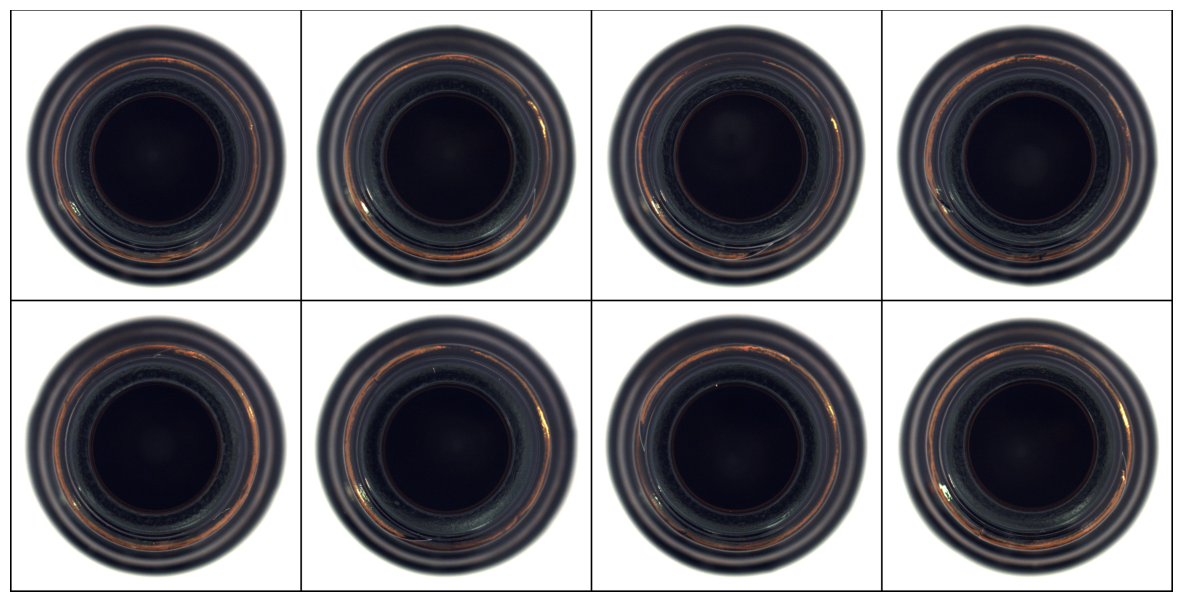

In [639]:
plot_batch(batch)

In [590]:

feature_extractor = pipeline(
    model="facebook/dinov3-vits16-pretrain-lvd1689m",
    task="image-feature-extraction",
    token=token
)

Loading weights: 100%|█████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 7146.25it/s]


In [640]:
from torchvision.transforms import ToPILImage

to_pil = ToPILImage()

imgs = [to_pil(img) for img in batch['image']]
features = feature_extractor(imgs)

def get_cls(x):
    return np.stack([feat[0] for feat in x])

In [642]:
import torch
from transformers import AutoModel, AutoImageProcessor

model_id = "facebook/dinov3-vits16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to("mps").eval()

@torch.no_grad()
def get_cls_efficient(batch_tensor):
    """
    Extracts only the CLS embeddings directly on the GPU.
    batch_tensor: PyTorch tensor from Anomalib (B, C, H, W)
    """
    # Move to GPU
    inputs = batch_tensor.to("mps")
    
    # Forward pass
    outputs = model(inputs)
    
    # Slice only the CLS token (Index 0)
    # Output shape: [Batch_Size, 384]
    cls_embeddings = outputs.last_hidden_state[:, 0, :]
    
    return cls_embeddings.cpu().numpy()

# Usage:
cls_features = get_cls_efficient(batch['image'])

Loading weights: 100%|█████████████████████████████████████████████████████████████| 211/211 [00:00<00:00, 6234.31it/s]


RuntimeError: MPS backend out of memory (MPS allocated: 17.30 GiB, other allocations: 26.69 MiB, max allowed: 18.13 GiB). Tried to allocate 1.76 GiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

In [594]:
np.linalg.norm(get_cls(features))

np.float64(9.46817422138203)

In [503]:
len(features[0][0])

384

In [500]:
[len(feat) for feat in features[0]]

[384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384,
 384